# 4. Truchet Tiles: Chance on a Grid

Chapter 3 built pattern out of perfect obedience; chapter 2 taught dice to behave. Today the two meet: a rigid grid where every cell flips a coin, and out of pure local chance grow paths, loops and currents that nobody drew.

## Today's destination

A field of more than two and a half thousand tiles, each carrying the same two quarter-circle arcs, each rotated by the flip of a weighted coin. Ink on paper, nothing else. Look longer and the maze starts to flow: a soft diagonal current runs through it, put there not by any drawn line but by a lean in the coin: 62 to 38 instead of fifty-fifty. By the end of today you can tile fields like this from any vocabulary of tiles you invent, and steer their weather.

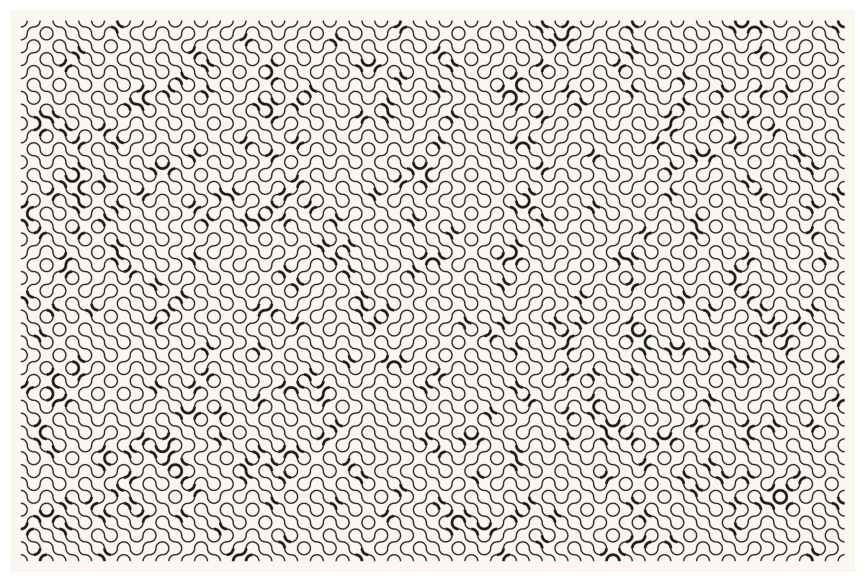

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch04_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(11, 7.3))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: a priest, a metallurgist, and one line of BASIC

In 1704 the Académie Royale des Sciences in Paris printed a short memoir with an unassuming title, *Mémoire sur les combinaisons* <a class="cite" href="#ref-truchet1704">(Truchet 1704)</a>, by **Sébastien Truchet** (1657-1729), a Discalced Carmelite priest and honorary member of the Académie. Truchet was the kind of practical polymath the age produced: he invented the first typographic point system, ancestor of the unit in which type is still measured, and helped construct the mathematically gridded Romain du Roi typeface for the royal press <a class="cite" href="#ref-andre1999">(André and Girou 1999)</a>. On a canal-engineering assignment near Orléans he came across a stack of ceramic tiles, each square split along the diagonal into two colors, and asked a combinatorial question no tiler had bothered to write down: a single such tile can sit in **four orientations**; what patterns can repeated copies make? His memoir catalogues the answers in careful engraved plates <a class="cite" href="#ref-smith1987">(Smith 1987)</a>. Note what he did *not* do: he did not invent the tile. He found one, and invented a way of thinking about it.

In 1722 a fellow Carmelite, **Dominique Douat**, expanded the memoir into a book-length treatise whose enumeration of arrangements runs far past Truchet's <a class="cite" href="#ref-douat1722">(Douat 1722)</a>; the art historian Ernst Gombrich called it the earliest treatise on the theory of design <a class="cite" href="#ref-gombrich1979">(Gombrich 1979)</a>. Then the idea slept for two and a half centuries, until the MIT metallurgist **Cyril Stanley Smith** reprinted Truchet in the art-and-science journal *Leonardo* in 1987 (with Pauline Boucher's English translation of the memoir) and added a quiet variation of his own: replace the two colored triangles with **two quarter-circle arcs** joining the midpoints of adjacent edges <a class="cite" href="#ref-smith1987">(Smith 1987)</a>. Nearly every "Truchet tiling" you will find today uses Smith's arc tile, drawn 283 years after its name.

The idea has a second, stranger monument. On a Commodore 64, the one-line program `10 PRINT CHR$(205.5+RND(1)); : GOTO 10` prints one of the machine's two diagonal-line characters at random, forever, and the screen fills with an endless maze. In 2012, ten authors (Nick Montfort, Casey Reas and eight others) published an entire MIT Press book about that single line <a class="cite" href="#ref-montfort2012">(Montfort et al. 2012)</a>. A whole monograph about one line of generative code: this book's thesis in miniature.

Chapter 3's patterns came from symmetry, every tile placed by law. Today the grid stays rigid but the law becomes a coin flip (chapter 2's oldest tool), and something new happens: arcs join across tile edges into paths and loops that no cell decided. Hold onto that sensation of structure appearing above the rules; it is the book's first taste of what chapter 13 will formally call emergence.

## The mathematics of a tile

A Truchet system needs only two decisions:

- **A unit cell** (Elementarzelle): one square tile design, drawn so it can sit in $k$ distinguishable orientations. Truchet's split square has $k = 4$; the 10 PRINT diagonal and Smith's arc tile each have $k = 2$ (rotating them twice gives the same picture back).
- **A choice rule**: for every cell of an $n \times m$ grid, pick one orientation, independently, by chance.

Because every cell chooses on its own, even tiny grids multiply into spaces of pictures no museum could hang; we will count one such space in a moment, and every run of this notebook hangs one picture from it on your screen.

## The 10 PRINT maze

The Commodore's two characters are two diagonals of a square: one rising, one falling. Here they are as coordinate pairs, our first two tiles. Each is a single line segment from one corner of the cell to the opposite one.

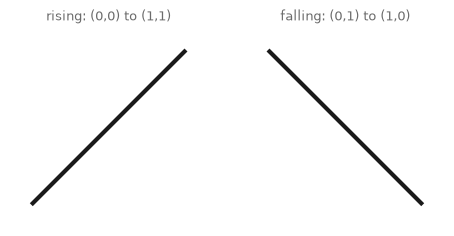

In [2]:
# the two 10 PRINT tiles: a rising and a falling diagonal
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(5.6, 2.8))
axes[0].plot([0, 1], [0, 1], color="#1A1A1A", lw=3)
axes[0].set_title("rising: (0,0) to (1,1)", fontsize=9, color="#6B6B6B")
axes[1].plot([0, 1], [1, 0], color="#1A1A1A", lw=3)
axes[1].set_title("falling: (0,1) to (1,0)", fontsize=9, color="#6B6B6B")
for ax in axes:
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

Now the maze: two nested loops visit every cell of the grid (chapter 0's row-and-column pattern, the same double loop that drew *Schotter* in chapter 1), and in each cell a seeded coin flip (chapter 2) places one diagonal or the other. Collecting all the segments and handing them to matplotlib in one bundle is the job of a **`LineCollection`**: one object holding thousands of little lines, drawn in a single stroke, hundreds of times faster than a thousand separate `plot` calls. It will draw nearly everything in this chapter.

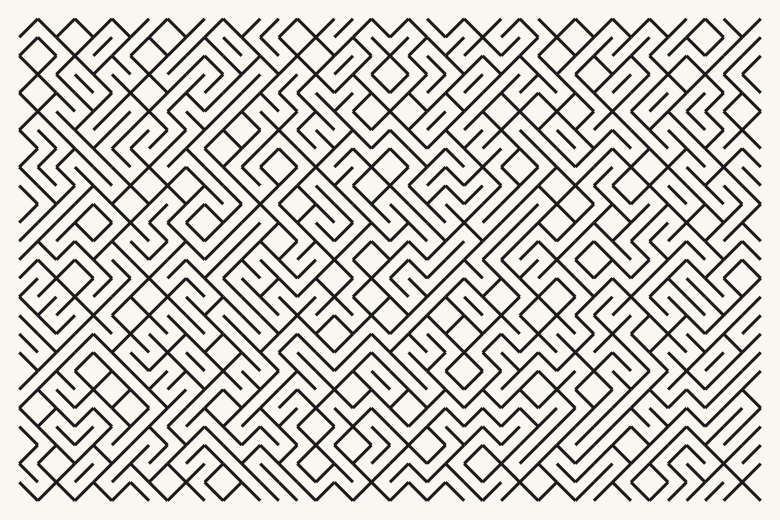

In [3]:
# the 10 PRINT maze: one coin flip per cell, one diagonal per flip
from matplotlib.collections import LineCollection
import sys
sys.path.append("..")                       # make the course package importable
from agap.helpers import PAPER, PALETTES, save_artwork

def ten_print(cols=40, rows=26, p_rising=0.5, seed=10, lw=2.2, ink="#1A1A1A"):
    rng = np.random.default_rng(seed)
    segments = []
    for row in range(rows):
        for col in range(cols):
            if rng.random() < p_rising:
                segments.append([(col, row), (col + 1, row + 1)])
            else:
                segments.append([(col, row + 1), (col + 1, row)])
    fig, ax = plt.subplots(figsize=(10, 6.5), facecolor=PAPER)
    ax.add_collection(LineCollection(segments, colors=ink, linewidths=lw))
    ax.set_xlim(-0.5, cols + 0.5)
    ax.set_ylim(-0.5, rows + 0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

ten_print()

There it is: the Commodore screen, in three honest ingredients (a double loop, a coin, a bundle of segments). Nobody planned the corridors, yet your eye finds them instantly, along with staircases, diamonds and little closed rooms. The maze exists entirely in your reading of it; the program only ever thought about one cell at a time.

**Try it.** Re-run with a different `seed`: a fresh maze every time, one picture drawn from an unthinkably large deck. How large? Independent choices multiply: an $n \times m$ grid of $k$-orientation tiles offers

$$k^{\,n \cdot m}$$

pictures, read aloud: *k multiplied by itself, once per cell* (chapter 0 taught powers as repeated multiplication). Ask Python:

In [4]:
# how many different mazes can this grid show?
cells_in_grid = 40 * 26
mazes = 2 ** cells_in_grid          # two choices per cell, independent
print(f"grid cells:  {cells_in_grid}")
print(f"possible mazes: a number with {len(str(mazes))} digits")
print(f"for comparison, a 5 by 5 grid alone allows {2 ** 25:,} mazes")

grid cells:  1040
possible mazes: a number with 314 digits
for comparison, a 5 by 5 grid alone allows 33,554,432 mazes


A number with 314 digits. (Physicists estimate the atoms in the observable universe with about 80 digits.) This is the everyday arithmetic of generative art: even the smallest system multiplies into a space of pictures no one will ever exhaust, and a seed is simply a bookmark in that space (chapter 2's contract, still holding).

## The Smith tile and the midpoint contract

Smith's 1987 variation replaces the diagonal with **two quarter-circle arcs**. Each arc is centered on a corner of the cell with radius one half, so it begins and ends exactly at the **midpoints of the cell's edges**. We build the arcs ourselves from chapter 3's unit circle (a point at angle $\theta$ on a circle of radius $r$ around a center sits at $x = c_x + r\cos\theta$, $y = c_y + r\sin\theta$); no ready-made patch, just trigonometry sampled along `np.linspace`.

In [5]:
# one quarter-circle arc, sampled as 24 short segments of trigonometry
QUARTER = np.linspace(0, np.pi / 2, 24)   # a quarter turn, finely sliced

def arc(center, start_angle):
    angles = start_angle + QUARTER
    return np.column_stack([center[0] + 0.5 * np.cos(angles),
                            center[1] + 0.5 * np.sin(angles)])

def smith_tile(col, row, orientation):
    if orientation == 0:      # arcs hugging the lower-left and upper-right corners
        return [arc((col, row), 0), arc((col + 1, row + 1), np.pi)]
    else:                     # the same tile, rotated a quarter turn
        return [arc((col + 1, row), np.pi / 2), arc((col, row + 1), -np.pi / 2)]

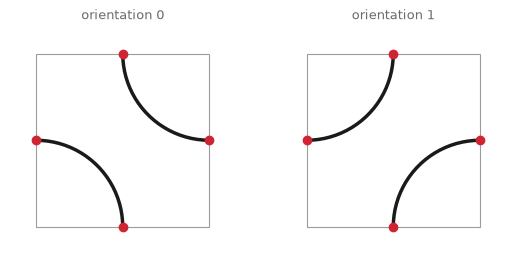

In [6]:
# the two orientations, with every edge midpoint marked
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.2))
for ax, orientation in zip(axes, [0, 1]):
    for stroke in smith_tile(0, 0, orientation):
        ax.plot(stroke[:, 0], stroke[:, 1], color="#1A1A1A", lw=2.5)
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                               edgecolor="#9C9C9C", lw=0.8))
    midpoints = [(0.5, 0), (1, 0.5), (0.5, 1), (0, 0.5)]
    for mx, my in midpoints:
        ax.plot(mx, my, "o", color="#D02433", markersize=6)
    ax.set_title(f"orientation {orientation}", fontsize=9, color="#6B6B6B")
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

The red dots are the proof, and it fits in one sentence. **Both orientations touch each edge at exactly the same four points: the midpoints.** When two tiles share an edge, they share that edge's midpoint, so an arc ending there always finds an arc (from one orientation or the other) beginning there. Every stroke continues across every border, *no matter how any coin lands*. Truchet's grid guarantees the meeting places; chance only decides what happens between them.

That is why tiling this tile at random produces not scattered arcs but **paths**: connected ink routes that wander from tile to tile, and here and there close into loops. The paths are the first objects in this book that exist only at the scale of the whole picture; no tile knows it is part of one.

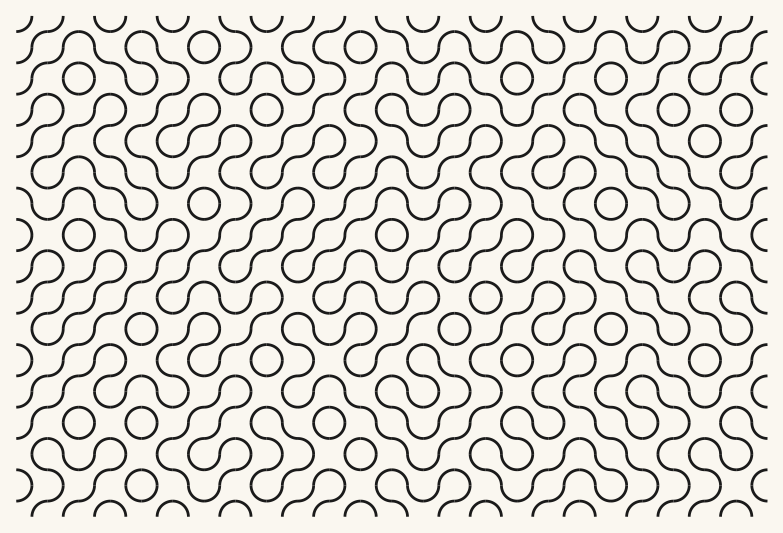

In [7]:
# tile the Smith tile at random: the classic Truchet field
def truchet_arcs(cols=24, rows=16, weights=(0.5, 0.5), seed=4, lw=2.0,
                 ink="#1A1A1A", figwidth=10):
    rng = np.random.default_rng(seed)
    strokes = []
    for row in range(rows):
        for col in range(cols):
            orientation = rng.choice(2, p=weights)   # chapter 2's weighted choice
            strokes += smith_tile(col, row, orientation)
    fig, ax = plt.subplots(figsize=(figwidth, figwidth * rows / cols),
                           facecolor=PAPER)
    ax.add_collection(LineCollection(strokes, colors=ink, linewidths=lw))
    ax.set_xlim(-0.2, cols + 0.2)
    ax.set_ylim(-0.2, rows + 0.2)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

truchet_arcs(seed=4)

**Look and compare.** Put this beside the 10 PRINT maze. Same grid, same coin, same two-orientation logic, yet the temperament is opposite: the maze is all elbows and the arc field is all hips. Trace one line of ink with your eye until it exits the frame or bites its own tail. How many tiles did it cross? Nobody chose that number.

**Try it.** Two or three different seeds. The circles that appear where four arcs close: do they show up in every run? (They are two-tile loops, the shortest the grammar allows, and chance mints a steady supply of them.)

## Weighted weather

A fair coin has no mood. Chapter 2 taught the fix: hand `rng.choice` uneven weights and randomness acquires a temperament. Biasing one orientation makes its diagonal direction pile up into long runs, and a *current* begins to flow through the maze; the grain is statistical, visible everywhere and locatable nowhere.

weights (0.50, 0.50): fair coin


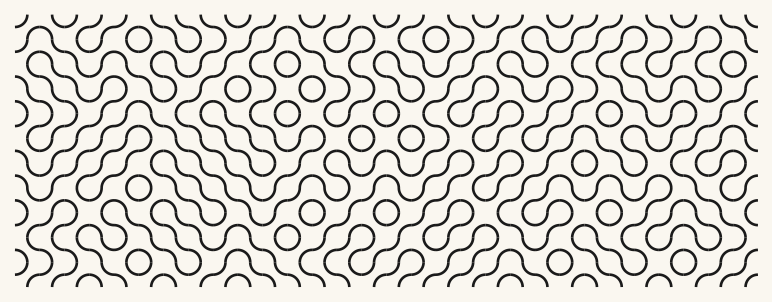

weights (0.72, 0.28): leaning


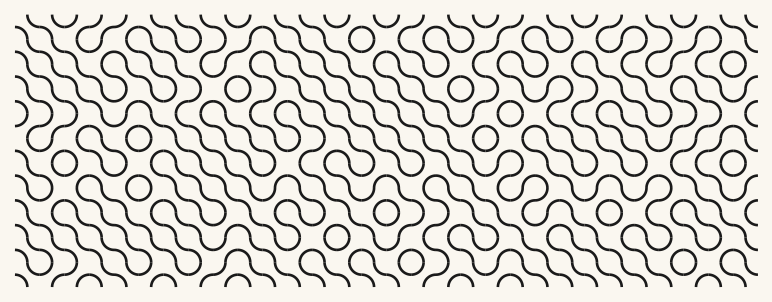

weights (0.92, 0.08): streaming


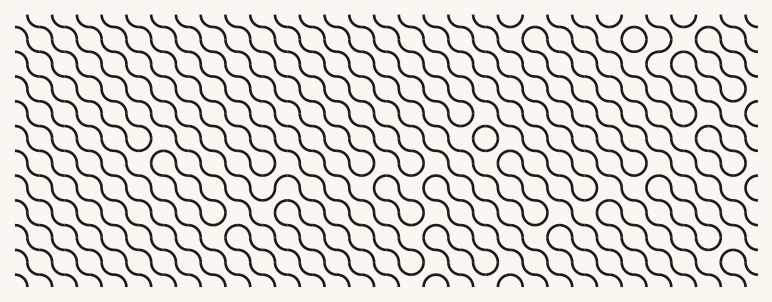

In [8]:
# one dial, three climates: bias the orientation coin
for p_first, label in [(0.5, "fair coin"), (0.72, "leaning"), (0.92, "streaming")]:
    print(f"weights ({p_first:.2f}, {1 - p_first:.2f}): {label}")
    truchet_arcs(cols=30, rows=11, weights=(p_first, 1 - p_first), seed=7,
                 lw=1.9, figwidth=10)

**Look and compare.** Somewhere between 0.72 and 0.92 the picture stops being a maze with a mood and becomes a *flow* interrupted by knots. Where exactly is that boundary for your eye? Hold the question; it is exercise (a), and it has no wrong answer, only your answer.

## A bigger vocabulary: the crossing and the blank

Nothing limits a tile set to one design in two poses. Any tile that **honors the midpoint contract** (touch edges only at midpoints) can join the deck, and the choice of deck changes the pattern's whole grammar. We add two: a **crossing** (straight lines joining opposite midpoints) and a **blank** (no ink at all). The blank deliberately breaks the contract's promise of continuation: arcs arriving at its border simply stop. Used sparingly, that is not a bug but breathing room, the rests between the notes.

In [9]:
# four tile functions, one dictionary: the deck we will draw from
def arc0_tile(col, row):
    return smith_tile(col, row, 0)

def arc1_tile(col, row):
    return smith_tile(col, row, 1)

def cross_tile(col, row):
    return [np.array([(col + 0.5, row), (col + 0.5, row + 1)]),
            np.array([(col, row + 0.5), (col + 1, row + 0.5)])]

def blank_tile(col, row):
    return []

TILES = {"arc0": arc0_tile, "arc1": arc1_tile,
         "cross": cross_tile, "blank": blank_tile}

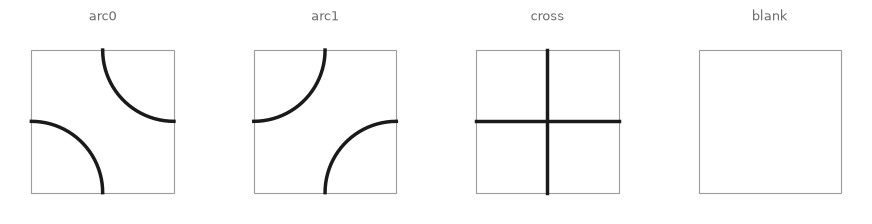

In [10]:
# the vocabulary so far: four tiles, one contract
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
for ax, name in zip(axes, TILES):
    for stroke in TILES[name](0, 0):
        ax.plot(stroke[:, 0], stroke[:, 1], color="#1A1A1A", lw=2.5)
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                               edgecolor="#9C9C9C", lw=0.8))
    ax.set_title(name, fontsize=9, color="#6B6B6B")
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

(One new habit in that cell: `TILES` stores *functions* as its values. A function is a thing in Python, storable like any number or string, and the dictionary hands us the right one by name, chapter 0's lookup-by-key with drawing recipes inside. The tiler below never needs to know which tiles exist; it just asks the dictionary.)

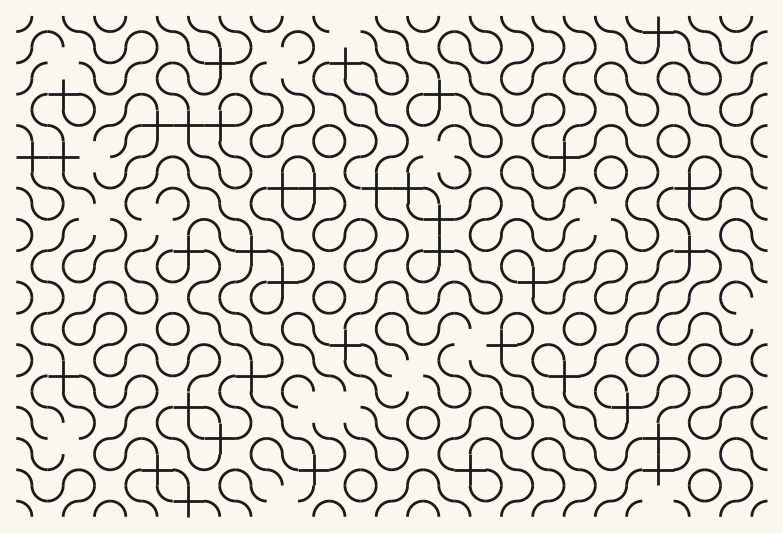

In [11]:
# the general tiler: any tile names, any weights
def truchet_field(cols=24, rows=16, tiles=("arc0", "arc1"),
                  weights=(0.5, 0.5), seed=4, lw=2.0, ink="#1A1A1A",
                  ax=None, figwidth=10):
    rng = np.random.default_rng(seed)
    strokes = []
    for row in range(rows):
        for col in range(cols):
            name = tiles[rng.choice(len(tiles), p=weights)]
            strokes += TILES[name](col, row)
    if ax is None:
        fig, ax = plt.subplots(figsize=(figwidth, figwidth * rows / cols),
                               facecolor=PAPER)
    ax.add_collection(LineCollection(strokes, colors=ink, linewidths=lw))
    ax.set_xlim(-0.2, cols + 0.2)
    ax.set_ylim(-0.2, rows + 0.2)
    ax.set_aspect("equal")
    ax.axis("off")

truchet_field(tiles=("arc0", "arc1", "cross", "blank"),
              weights=(0.42, 0.42, 0.10, 0.06), seed=11)
plt.show()

An opinionated weight vector: mostly arcs, a tenth crossings, a pinch of silence. The crossings do something arcs never could: they let two ink paths *intersect*, which the pure arc grammar forbids (arcs only ever meet end to end). The blanks punch quiet holes where lines end mid-field. Small numbers, big grammar shifts.

**Try it.** Set the blank weight to 0.3: the pattern disintegrates into archipelagos. At what weight does it stop reading as a *fabric* and start reading as *islands on a ground*?

## Style passes: the pen and the palette

Two finishing moves, both borrowed. First, **line-width rhythm**: instead of one pen, let each tile draw with a randomly chosen thick or thin stroke (a second, independent weighted choice per cell). Second, **color**: hand each tile a color from one of our palettes (`agap.PALETTES`, in service since chapter 2). Both choices ride on the same machinery as the orientation coin.

In [12]:
# a styled tiler: per-tile pen width and palette color
def truchet_styled(cols=26, rows=17, tiles=("arc0", "arc1"), weights=(0.5, 0.5),
                   palette=("#1A1A1A",), widths=(1.4, 3.0), thick_share=0.15,
                   seed=4, ground=PAPER, ax=None, figwidth=10):
    rng = np.random.default_rng(seed)
    strokes, stroke_colors, stroke_widths = [], [], []
    for row in range(rows):
        for col in range(cols):
            name = tiles[rng.choice(len(tiles), p=weights)]
            color = palette[rng.integers(0, len(palette))]
            width = widths[1] if rng.random() < thick_share else widths[0]
            for stroke in TILES[name](col, row):
                strokes.append(stroke)
                stroke_colors.append(color)
                stroke_widths.append(width)
    if ax is None:
        fig, ax = plt.subplots(figsize=(figwidth, figwidth * rows / cols),
                               facecolor=ground)
    # paint the ground ourselves: axis("off") hides the axes' own background
    ax.add_patch(plt.Rectangle((-0.2, -0.2), cols + 0.4, rows + 0.4,
                               color=ground, zorder=0))
    ax.add_collection(LineCollection(strokes, colors=stroke_colors,
                                     linewidths=stroke_widths))
    ax.set_xlim(-0.2, cols + 0.2)
    ax.set_ylim(-0.2, rows + 0.2)
    ax.set_aspect("equal")
    ax.axis("off")

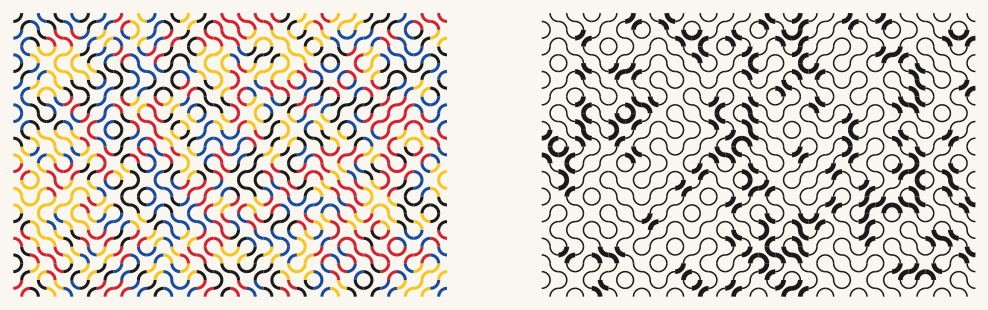

In [13]:
# two dress rehearsals: Bauhaus primaries, and thick-and-thin ink
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1))
truchet_styled(palette=PALETTES["bauhaus"][:4], thick_share=0.0,
               widths=(2.2, 2.2), seed=5, ax=axes[0])
truchet_styled(palette=("#1A1A1A",), widths=(1.1, 3.4), thick_share=0.22,
               seed=5, ax=axes[1])
fig.patch.set_facecolor(PAPER)
plt.show()

**Look and compare.** The Bauhaus version reads as textile, the thick-and-thin version as calligraphy. Yet the geometry is identical (same seed, same orientations). This is chapter 6's lesson arriving early: what a system *is* and what it *wears* are separate decisions, and the wearing is yours.

## Playground: four temperaments

The finished instrument, played four ways. Grid density, tile set, weights, pen, palette: five dials, four studies.

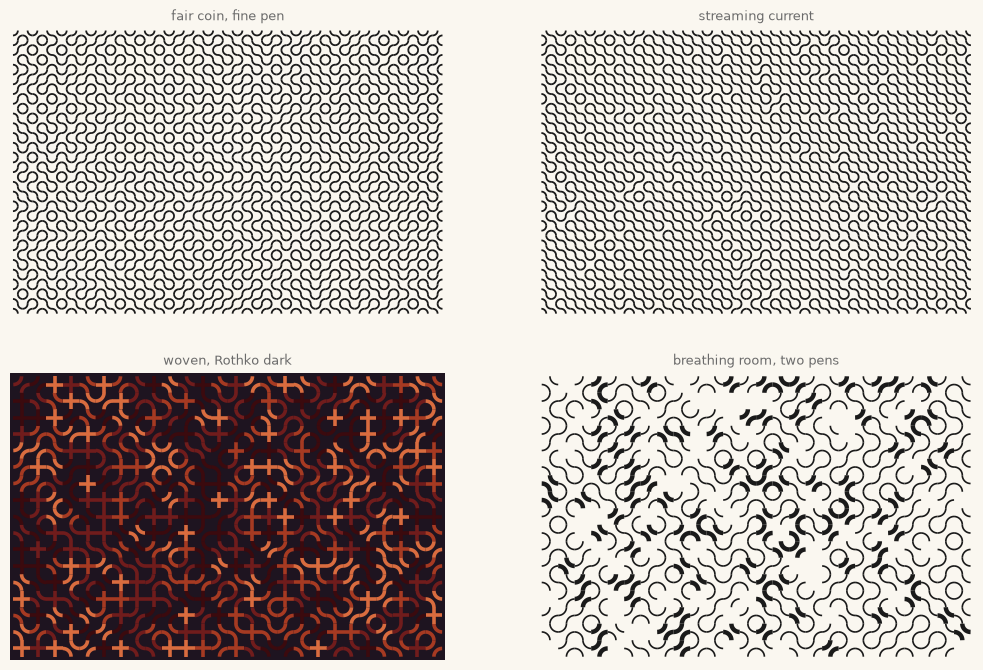

In [14]:
# four studies from one machine
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
fig.patch.set_facecolor(PAPER)

truchet_styled(cols=44, rows=29, tiles=("arc0", "arc1"), weights=(0.5, 0.5),
               widths=(1.3, 1.3), thick_share=0, seed=2, ax=axes[0, 0])
axes[0, 0].set_title("fair coin, fine pen", fontsize=9, color="#6B6B6B")

truchet_styled(cols=44, rows=29, tiles=("arc0", "arc1"), weights=(0.85, 0.15),
               widths=(1.3, 1.3), thick_share=0, seed=2, ax=axes[0, 1])
axes[0, 1].set_title("streaming current", fontsize=9, color="#6B6B6B")

truchet_styled(cols=26, rows=17, tiles=("arc0", "arc1", "cross"),
               weights=(0.33, 0.33, 0.34), palette=PALETTES["rothko_dark"][:4],
               widths=(2.6, 2.6), thick_share=0, seed=9, ground="#1E1420",
               ax=axes[1, 0])
axes[1, 0].set_title("woven, Rothko dark", fontsize=9, color="#6B6B6B")

truchet_styled(cols=26, rows=17, tiles=("arc0", "arc1", "blank"),
               weights=(0.42, 0.42, 0.16), widths=(1.2, 3.2), thick_share=0.25,
               seed=13, ax=axes[1, 1])
axes[1, 1].set_title("breathing room, two pens", fontsize=9, color="#6B6B6B")
plt.show()

**Look and compare.** Which of the four feels calmest, and which parameter is responsible? (Candidates: the weights, the tile set, the pen.) Notice that the two upper studies differ *only* in weights, and the two lower ones share their weights almost exactly but not their vocabulary.

## Export your artwork

Your turn: pick a tile set, weights, palette, pens, seed. Replace `yourname` with your name and run; the tiling lands in the course gallery folder at print quality.

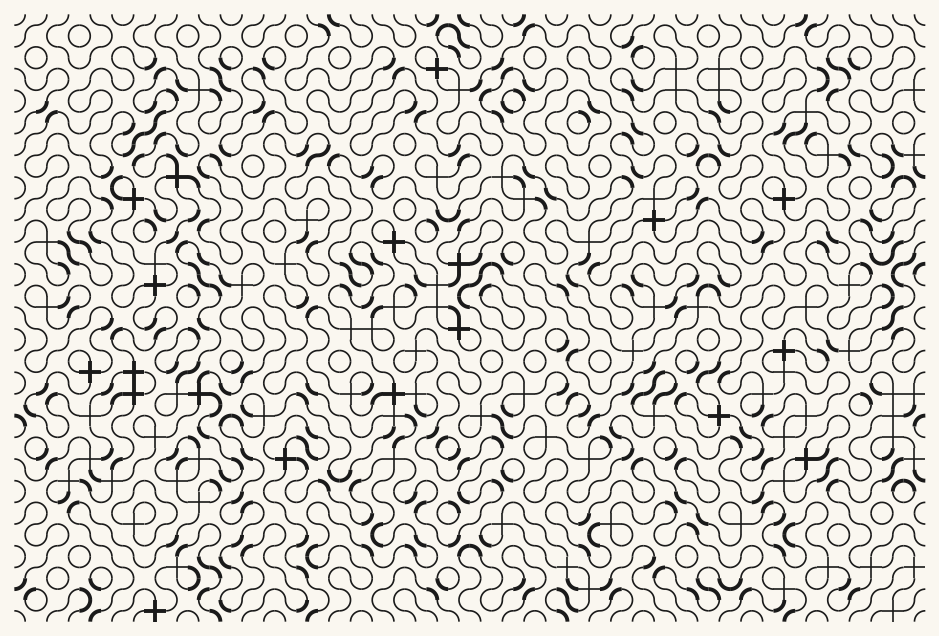

saved: assets/outputs/ch04_yourname.png


In [15]:
# save YOUR tiling: tune the dials, replace 'yourname'
my_artwork, my_ax = plt.subplots(figsize=(12, 8), facecolor=PAPER)
truchet_styled(cols=42, rows=28, tiles=("arc0", "arc1", "cross"),
               weights=(0.46, 0.46, 0.08), palette=("#1A1A1A",),
               widths=(1.2, 2.8), thick_share=0.18, seed=24, ax=my_ax)
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=4)

## Exercises

**(a) Parameter exploration: where the maze becomes a river.** Tile the arc pair at weights 0.5, 0.6, 0.7, 0.8, 0.9 and 0.95 (same seed throughout). Find the weight at which the picture stops reading as *maze* and starts reading as *flow*, and write one sentence defending your threshold. Then check whether your threshold survives a change of seed.

**(b) Code modification: a third voice for the arc duet.** The random set in `truchet_arcs` knows only the two arc orientations. Give the *general* tiler a new tile of your own making: a **double tile** that draws all four arcs at once (both orientations in one cell), so paths can weave through it in two layers. Add it to `TILES` as a plain function (no shortcuts) and re-tile with weights `(0.4, 0.4, 0.2)`.

<details><summary>Solution</summary>

```python
def double_tile(col, row):
    return smith_tile(col, row, 0) + smith_tile(col, row, 1)

TILES["double"] = double_tile
truchet_field(tiles=("arc0", "arc1", "double"), weights=(0.4, 0.4, 0.2),
              seed=6, lw=1.8)
plt.show()
```

The double tile honors the midpoint contract twice over: all four midpoints are used, so every neighbor connects on every side. Where it lands, the field visibly thickens into a knot; at weight 0.2 the knots chain into ropes.
</details>

**(c) Creative challenge: sign the contract yourself.** Design a tile nobody has shown you, with one rule: it may touch its edges **only at the midpoints**. (Ideas: a single arc plus one straight segment; a U-turn that enters and leaves on the same side; a spiral that dead-ends in the middle, contract be damned, and see what dead ends do at scale.) Add it to `TILES`, tile a large field, and give the resulting pattern a name, as Truchet's engravers numbered their plates. Prove your contract holds by looking: does every line continue across every border?

## Further reading

- Cyril Stanley Smith, with a translation by Pauline Boucher, "The Tiling Patterns of Sebastien Truchet and the Topology of Structural Hierarchy", *Leonardo* 20, no. 4 (1987): 373-385: the revival itself, with Truchet's 1704 memoir in English; Smith reads the tiles as a lesson in how structure lives at more than one scale.
- Nick Montfort, Patsy Baudoin, John Bell, Ian Bogost, Jeremy Douglass, Mark C. Marino, Michael Mateas, Casey Reas, Mark Sample and Noah Vawter, *10 PRINT CHR$(205.5+RND(1)); : GOTO 10* (MIT Press, 2012): ten authors, one line of BASIC; freely available as a PDF at 10print.org.
- Christopher Carlson, "Multi-Scale Truchet Patterns", *Bridges Conference Proceedings* (2018), 39-44: Smith's arc tiles generalized across nested scales; the paper's figures are a gallery in themselves.
- Truchet's original *Mémoire sur les combinaisons* (1704) is on the Bibliothèque nationale's Gallica portal, plates included, for readers who want to see the engravings.

## References

- <span id="ref-andre1999"></span>André, J., and Girou, D. (1999). Father Truchet, the typographic point, the Romain du roi, and tilings. *TUGboat*, 20(1), 8–14. [tug.org/TUGboat/tb20-1/tb62andr.pdf](https://www.tug.org/TUGboat/tb20-1/tb62andr.pdf). Truchet as inventor of the typographic point and designer of the Romain du Roi.
- <span id="ref-douat1722"></span>Douat, D. (1722). *Methode pour faire une infinité de desseins differens avec des carreaux mi-partis de deux couleurs par une ligne diagonale*. Paris. [gallica.bnf.fr](https://gallica.bnf.fr/ark:/12148/bpt6k5823204r). The book-length expansion of Truchet's memoir, digitized by the Bibliothèque nationale.
- <span id="ref-gombrich1979"></span>Gombrich, E. H. (1979). *The Sense of Order: A Study in the Psychology of Decorative Art*. Phaidon. Calls Douat's treatise "the earliest (and perhaps the rarest) treatise on the theory of design" (p. 70).
- <span id="ref-montfort2012"></span>Montfort, N., Baudoin, P., Bell, J., Bogost, I., Douglass, J., Marino, M. C., Mateas, M., Reas, C., Sample, M., and Vawter, N. (2012). *10 PRINT CHR$(205.5+RND(1)); : GOTO 10*. MIT Press. [10print.org](https://10print.org/).
- <span id="ref-smith1987"></span>Smith, C. S. (1987). The Tiling Patterns of Sebastien Truchet and the Topology of Structural Hierarchy (with a translation of Truchet's memoir by P. Boucher). *Leonardo*, 20(4), 373–385. [doi:10.2307/1578535](https://doi.org/10.2307/1578535). The 1987 revival, the canal-tiles origin story, and the arc tile.
- <span id="ref-truchet1704"></span>Truchet, S. (1704). Mémoire sur les combinaisons. *Mémoires de l'Académie Royale des Sciences*, 363–372. [gallica.bnf.fr](https://gallica.bnf.fr/ark:/12148/bpt6k3486m).

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image at the top of the notebook: 64 by 42 tiles of the Smith pair, weights 0.62 to 0.38 (the gentle lean that makes the current), one ink, two pens, seed 1704 in the inventor's honor. It runs automatically with *Restart & Run All*.

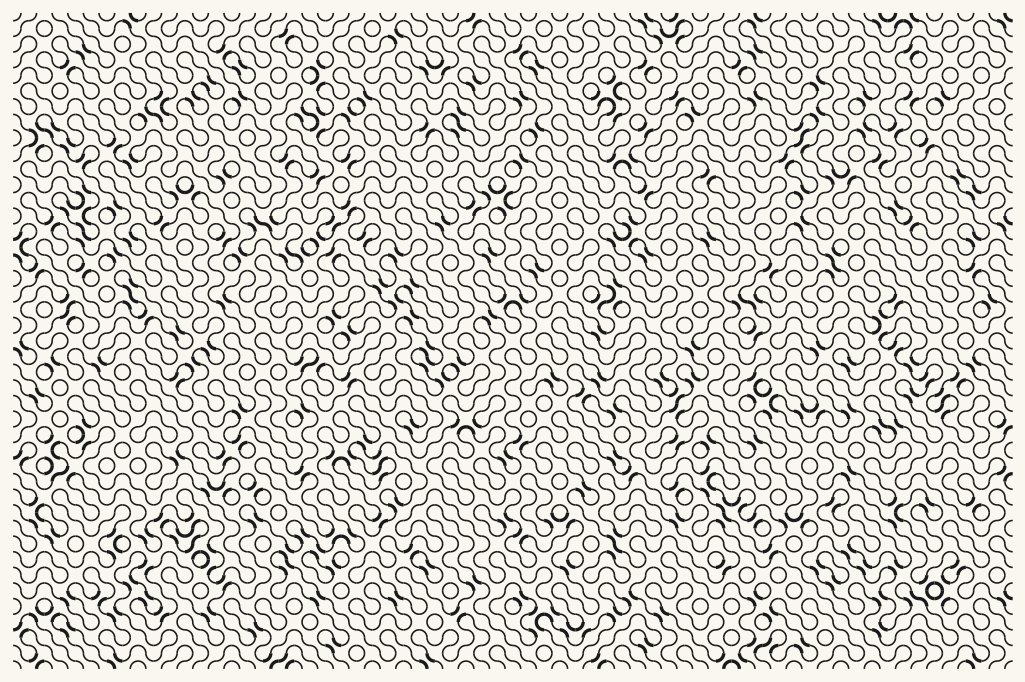

saved: assets/outputs/ch04_showpiece.png


In [16]:
# regenerate this chapter's showpiece: the leaning field
showpiece, sp_ax = plt.subplots(figsize=(13, 8.6), facecolor=PAPER)
truchet_styled(cols=64, rows=42, tiles=("arc0", "arc1"), weights=(0.62, 0.38),
               palette=("#1A1A1A",), widths=(1.15, 2.4), thick_share=0.12,
               seed=1704, ax=sp_ax)
plt.show()
saved_path = save_artwork(showpiece, "showpiece", chapter=4)